In [1]:
import re
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scorecardpipeline import *

init_setting()

pd.set_option("display.max_columns", None)      # 显示所有列
pd.set_option("display.max_rows", None)         # 显示所有行
pd.set_option("display.width", None)            # 不按固定宽度折叠
pd.set_option("display.max_colwidth", None)     # 单元格内容不截断

target = 'target'

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel(r'../data/modeling_Samples.xlsx')
df['order_sn'] = df['order_sn'].astype('object')
num_cols = df.select_dtypes(include=['int', 'float']).columns
df[num_cols] = df[num_cols].astype('float64')
df.dropna(subset=['apply_time1'],inplace=True)

In [3]:
df = df[df['is_mature']==True].copy()

In [4]:
mask = df['flag_blackgraylevel'].eq(0)
df.loc[mask, 'bgl_level'] = df.loc[mask, 'bgl_level'].fillna(0)

In [5]:
del_na = ['scorecust6','debtrepaystresspro_S1_1','scoreafysbase_V2_0','scoreafywbase_V2_0','scorewisgnlbase_V3_1','scorewis_S2_5','scorewisgnlbase_V3_0','scoreywbase_V3_0','scoreysbase_V3_0','scorertstdd1_V1_2','scoreafysstd_V2_6','scoreafywstd_V2_5','scoreywpro_V1_3','scorertstdc1_V1_2','scoreyspro_V1_3','scorertstdd1_V1_5','scoreysstd_V3_3_1','scoreywstd_V3_3','flag_scorefxsbindex_qlty','scorefxsbindex_qlty_scoreshwdxbasea','scorefxsbindex_qlty_scoreqsycbasea','scorefxsbindex_qlty_scorefxsbbasea','scorefxsbindex_qlty_scoreglycbasea','scorefxsbindex_qlty_scorexfxwycbasea','scorefxsbindex_qlty_scorelyyybasea','scorefxsbindex_qlty_scoresqtcbasea',
'lend_time_distance','ident_last_apply_time','lend_time','overdue_money','zhili_d6_1','zhili_d6_4','zhili_d6_5','zhili_d6_6','zhili_d1_4','zhili_d1_7','zhili_d1_8','zhili_d1_9','network_triple_elements','identity_two_elements','fee_status',
'bgl_level','scorefxsbindex_norm_scoreqsycbaseb','scorefxsbindex_norm_scoreglycbaseb','scorefxsbindex_norm_scoreshwdxbaseb','zhidun_mx1h_score','zhili_d3_7','score_norm_explain','scorecust2','scorecust4','仟盈反欺诈V1','仟盈客群资质分V2','仟盈通用分V2','仟盈通用分11_8','仟盈通用分11_6','仟盈通用分11_5','仟盈通用分11_2','仟盈通用分11_1','zhili_d4_4','time_online','counts','号码使用时间较短','命中新增风险特征规则','lend_number3','lend_number24','ident_contain_phone_ct','repay_fail1','repay_succ3','nllenders','scorefxsbindex_norm_scorexfxwycbaseb','scorefxsbindex_norm_scorefxsbbaseb','scorefxsbindex_norm_scorelyyybaseb','scorefxsbindex_norm_scoresqtcbaseb','scorecust3','scorecust5','仟盈客群等级V2','仟盈下沉分','仟盈互金分v2','仟盈分期分v1','仟盈互金分4','beta_pro_v2','zhili_d3_4','zhili_d3_8','zhili_d3_9','zhili_d4_9','yumingheng_test_sample__zhidun_mx1h_score','yumingheng_test_sample__beta_pro_v2','m3_phone_to_idcard_time','m6_night_apply_agency_time','m3_night_apply_time','m12_night_apply_agency_time','m1_night_apply_agency_time','m6_night_apply_time','m1_night_apply_time','m12_night_apply_time','m3_night_apply_agency_time','二要素验证不一致','年龄较小','d7_night_apply_agency_time','d7_night_apply_time','credit_rent','overdue_mechanism_number','m3_idcard_to_phone_time','phone_contain_ident_ct','result_xd','census_register_high_risk_area','lenders','beta_pro_v1','zhixiang_score','zhitong_ultra_v4_score','zc_score01','zc_score02']

df.drop(columns=del_na,axis=1,errors='ignore',inplace=True)

del_list =['rent_days_sum','mob_end','label_mature_date','min_30_inst_min','has_early_close','flag_blackgraylevel']
df.drop(columns=del_list,axis=1,errors='ignore',inplace=True)

In [6]:
xyp_cols = [
    col for col in df.columns
    if str(col).startswith('xyp_')
]

df = df.drop(columns=xyp_cols)

In [7]:
# todo 删除单一特征
drop_cols = [col for col in df.columns if col != 'target' and df[col].nunique() <= 1]
print("删除的常数特征：", drop_cols)

df = df.drop(columns=drop_cols,errors='ignore')

删除的常数特征： ['is_mature', 'flag_scorefxsbindex_norm', 'flag_score', 'uncleared_counts', 'idcard_hit_fztj', 'phone_hit_txxh', 'idcard_hit_clzlwy', 'phone_hit_xjhm', 'idcard_hit_gywzcc', 'lend_money12', 'lend_money24', 'lend_money3', 'lend_money1', 'lend_money6']


In [8]:
# 对照值：逾期和履约金额区间
amount_range_map = {
    '0': 0,'(0,500)': 1,'[500,1000)': 2,'[1000,2000)': 3,'[2000,3000)': 4,
    '[3000,5000)': 5,'[5000,10000)': 6,'[10000,20000)': 7,'[20000,30000)': 8,
    '[30000,50000)': 9,'[50000,100000)': 10,'[100000,200000)': 11,
    '[200000,300000)': 12,'[300000,500000)': 13,'[500000,1000000)': 14,
    '[1000000,+)': 15,'[50000,+)': 10,
}


def normalize_amount_range(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip()
    if text in {'', '--', 'nan', 'NaN'}:
        return pd.NA
    if text in {'0', '0.0'}:
        return '0'

    text = (
        text.replace('（', '(')
            .replace('）', ')')
            .replace('【', '[')
            .replace('】', ']')
            .replace('，', ',')
            .replace('∞', '+')
            .replace(' ', '')
    )
    text = re.sub(r'(?<=\d)[-－—–](?=\d|\+)', ',', text)
    return text


def encode_amount_range(value):
    normalized = normalize_amount_range(value)
    if pd.isna(normalized):
        return pd.NA
    return amount_range_map.get(normalized, pd.NA)


amount_range_cols = [
    col for col in df.columns
    if col.startswith('repay_money')
    and (
        pd.api.types.is_object_dtype(df[col])
        or pd.api.types.is_string_dtype(df[col])
    )
]

unknown_amount_values = {}
for col in amount_range_cols:
    encoded = df[col].map(encode_amount_range)
    unknown = df.loc[df[col].notna() & encoded.isna(), col].astype(str).unique()
    if len(unknown) > 0:
        unknown_amount_values[col] = sorted(unknown)

if unknown_amount_values:
    raise ValueError(f'存在未配置的金额区间: {unknown_amount_values}')

for col in amount_range_cols:
    df[col] = df[col].map(encode_amount_range).astype('Int64')

In [9]:
df = df.copy()

df['order_time'] = pd.to_datetime(df['order_time'], errors='coerce')
df['order_month'] = df['order_time'].dt.to_period('M')
# 去掉 order_time 为空的样本，避免时序切分异常
df_valid = df.loc[df['order_time'].notna()].copy()
# 按订单时间排序
df_valid = df_valid.sort_values('order_time').reset_index(drop=True)
# 2. 每个月样本量、坏样本数、违约率
monthly_bad_rate = (
    df_valid.groupby('order_month')
      .agg(
          sample_cnt=('target', 'size'),
          bad_cnt=('target', 'sum'),
          bad_rate=('target', 'mean'),
      )
      .reset_index()
)
monthly_bad_rate['order_month'] = monthly_bad_rate['order_month'].astype(str)
monthly_bad_rate['bad_rate'] = monthly_bad_rate['bad_rate'].round(4)
# 3. 按时间序列 + 样本比例切分
train_ratio = 0.85 
n = len(df_valid)
train_size = int(n * train_ratio)
train_df = df_valid.iloc[:train_size].copy()
oot_df = df_valid.iloc[train_size:].copy()
train_df['sample_split'] = 'train'
oot_df['sample_split'] = 'oot'
# 合并回完整样本
df_split = pd.concat([train_df, oot_df], axis=0).sort_index()
split_summary = (
    df_split.groupby('sample_split')
      .agg(
          sample_cnt=('target', 'size'),
          bad_cnt=('target', 'sum'),
          bad_rate=('target', 'mean'),
          min_order_time=('order_time', 'min'),
          max_order_time=('order_time', 'max'),
          min_month=('order_month', 'min'),
          max_month=('order_month', 'max'),
      )
      .reset_index()
)
split_summary['bad_rate'] = split_summary['bad_rate'].round(4)
split_summary[['min_month', 'max_month']] = split_summary[['min_month', 'max_month']].astype(str)
print("月度坏账率：")
display(monthly_bad_rate)

print("样本切分汇总：")
display(split_summary)

print("train 样本量：", train_df.shape)
print("oot 样本量：", oot_df.shape)

月度坏账率：


,order_month,sample_cnt,bad_cnt,bad_rate
0,2025-01,215,21.0000,0.0977
1,2025-02,513,48.0000,0.0936
2,2025-03,704,52.0000,0.0739
3,2025-04,842,79.0000,0.0938
4,2025-05,604,47.0000,0.0778
5,2025-06,1187,93.0000,0.0783
6,2025-07,718,54.0000,0.0752
7,2025-08,1163,78.0000,0.0671
8,2025-09,334,19.0000,0.0569
9,2025-10,69,1.0000,0.0145


样本切分汇总：


,sample_split,sample_cnt,bad_cnt,bad_rate,min_order_time,max_order_time,min_month,max_month
0,oot,953,58.0000,0.0609,2025-08-17 22:39:00,2025-10-09 16:13:00,2025-08,2025-10
1,train,5396,434.0000,0.0804,2025-01-04 15:05:00,2025-08-17 22:35:00,2025-01,2025-08


train 样本量： (5396, 55)
oot 样本量： (953, 55)


In [10]:
obj_cols = train_df.select_dtypes(include=['object','datetime','period[M]']).columns

train = train_df.drop(columns=obj_cols, errors='ignore')
test = oot_df.drop(columns=obj_cols, errors='ignore')

In [11]:
train_select = train.copy()
test_select =  test.copy()

In [12]:
del_bins = ['beta_pro_v1','zhixiang_score','zhitong_ultra_v4_score','zc_score01','zc_score02','repay_fail12','m1_apply_time','repay_fail3','repay_fail6','repay_fail24','apply_time3','repay_money1','repay_succ1','d7_apply_time', 'm3_apply_agency_time', 'm12_apply_agency_time', 'repay_money6', 'repay_succ12','repay_money12', 'm6_apply_time', 'm3_apply_time', 'm6_apply_agency_time','仟盈通用分v5','仟盈通用分11_4','scorecust1','zhili_d4_7'
]

train_select.drop(del_bins,axis=1,inplace=True,errors='ignore')
test_select.drop(del_bins,axis=1,inplace=True,errors='ignore')

### oot样本验证

In [13]:
df_oot = pd.read_excel(r'../data/oot用户标签验证_合并评分报告.xlsx')
df_oot.rename(columns={
    'beta_pro_v1': 'yumingheng_test_sample__beta_pro_v1', 
    'zc_score01': 'yumingheng_test_sample__zc_score01',
    'inst_6_ever_dpd15_flag': 'target'
}, inplace=True)
df_oot = df_oot.dropna(subset=['yumingheng_test_sample__zc_score01','仟盈信用分V1','apply_time1'])

In [14]:
# 初始化分箱器
combiner = Combiner(target='target', method='cart',min_bin_size=0.05, empty_separate=True)
# 训练
combiner.fit(train_select)

combiner.update({'d7_apply_agency_time': [1, 2, np.nan]})
combiner.update({'m1_apply_agency_time': [1, 3, np.nan]})
combiner.update({'m3_apply_agency_time': [1, 2, 3, np.nan]})
combiner.update({'m6_apply_agency_time': [1, 2, 3, np.nan]})
combiner.update({'m12_apply_agency_time': [1, 2, 4, 5, np.nan]})
combiner.update({'d7_apply_time': [1, 2, np.nan]})
combiner.update({'m1_apply_time': [1, 2, np.nan]})
combiner.update({'m3_apply_time': [1, 2, 3, np.nan]})
combiner.update({'m6_apply_time': [2, 5, np.nan]})
combiner.update({'m12_apply_time': [1, 2, 4, np.nan]})
combiner.update({'apply_time1': [2, 7, 20, np.nan]})
combiner.update({'apply_time3': [45, np.nan]})
combiner.update({'apply_time6': [8, 35, 74, np.nan]})
combiner.update({'apply_time12': [4, 23, 27, np.nan]})
combiner.update({'lend_number1': [12, np.nan]})
combiner.update({'lend_number6': [2, 4, 14, np.nan]})
combiner.update({'lend_number12': [13, 24, np.nan]})
combiner.update({'lend_number24': [5, 7, 9, np.nan]})
combiner.update({'repay_succ1': [2, 3, 4, 8, np.nan]})
combiner.update({'repay_succ3': [3, np.nan]})
combiner.update({'repay_succ6': [8, 30, np.nan]})
combiner.update({'repay_succ12': [4, 47, np.nan]})
combiner.update({'repay_succ24': [2, 3, 17, np.nan]})
combiner.update({'repay_money1': [2, 4, 6, np.nan]})
combiner.update({'repay_money3': [1, 3, np.nan]})
combiner.update({'repay_money6': [2, 3, 9, np.nan]})
combiner.update({'repay_money12': [1, 4, 7, np.nan]})
combiner.update({'repay_money24': [4, 8, np.nan]})
combiner.update({'cflenders': [2, 4, np.nan]})
combiner.update({'lenders': [5, 17, np.nan]})
combiner.update({'overdue_money': [1, 3, 4, np.nan]})
combiner.update({'census_register_high_risk_area': [1, np.nan]})
combiner.update({'多头查询次数多': [1, np.nan]})
combiner.update({'二要素验证不一致': [1, np.nan]})
combiner.update({'号码使用时间较短': [1, np.nan]})
combiner.update({'号码异常': [1, np.nan]})
combiner.update({'近1个月扣款失败次数较多': [1, np.nan]})
combiner.update({'近1个月网贷平台申请频繁': [1, np.nan]})
combiner.update({'近1周申请租赁平台较多': [1, np.nan]})
combiner.update({'近半年内存在逾期记录': [1, np.nan]})
combiner.update({'命中风险关注名单': [1, np.nan]})
combiner.update({'命中新增风险特征规则': [1, np.nan]})
combiner.update({'年龄较小': [1, np.nan]})
combiner.update({'年龄过大': [1, np.nan]})
combiner.update({'年龄过小': [1, np.nan]})
combiner.update({'三要素验证不一致': [1, np.nan]})
combiner.update({'身份证和手机号关联数据多': [1, np.nan]})
combiner.update({'司法案件匹配度高': [1, np.nan]})
combiner.update({'result_xd': [1, np.nan]})
combiner.update({'phone_contain_ident_ct': [1, np.nan]})
combiner.update({'network_triple_elements': [2, np.nan]})
combiner.update({'time_online': [0, 5, np.nan]})
combiner.update({'hit_risk_tagging_count': [4, np.nan]})
combiner.update({'ident_contain_phone_ct': [1, 2, np.nan]})
combiner.update({'ident_last_apply_diff_days': [199, 261, np.nan]})
combiner.update({'m3_idcard_to_phone_time': [3, np.nan]})
combiner.update({"scorecust1": [618.5,643.5,706.5,789.5,np.nan]})
combiner.update({"zhili_d4_7": [43.844,49.367,63.583,np.nan]})
combiner.update({"zhili_d4_8": [44.2698,57.3074,62.709,np.nan]})
combiner.update({"仟盈通用分11_7": [38,47.2427,59.0072,64.0859,68.3368,72,np.nan]})
combiner.update({"仟盈信用分V1": [26.5749,35.7699,84.875,98.7049, np.nan]})
combiner.update({"仟盈通用分v5": [45.5,66.5,np.nan]})
combiner.update({"仟盈通用分11_3": [54.4212 , 62.0919,np.nan]})
combiner.update({"仟盈通用分11_4": [40.3263,60.3901,np.nan]})
combiner.update({"仟盈通用分11_7": [47.2427,59.0072,64.0859,68.3368,np.nan]})
combiner.update({"仟盈通用分11_9": [37.4573,51.5872,60.4159,64.1506,np.nan]})
combiner.update({"仟盈通用反欺诈评分V4": [54,69,86,92,np.nan]})
# combiner.update({"beta_pro_v1": [430.5,484.5,537.5,602.5,np.nan]})
combiner.update({"yumingheng_test_sample__beta_pro_v1": [400,430.5,484.5,599.5,np.nan]})
# combiner.update({"zhixiang_score": [426.5,494.5,543.5,649.5,np.nan]})
combiner.update({"yumingheng_test_sample__zhixiang_score": [390,426.5,494.5,584.5,np.nan]})
# combiner.update({"zhitong_ultra_v4_score": [0.5015,0.6438,0.6944,np.nan]})
combiner.update({"yumingheng_test_sample__zhitong_ultra_v4_score": [0.5015,0.6438,0.6944,np.nan]})
# combiner.update({"zc_score01": [469.5,534.5,592.5,np.nan]})
combiner.update({"yumingheng_test_sample__zc_score01": [403,459.5,534.5,592.5,np.nan]})
# combiner.update({"zc_score02": [387.5,453.5,486.5,572.5,np.nan]})
combiner.update({"yumingheng_test_sample__zc_score02": [378,397,421.5,486.5,572.5,np.nan]})


train_bins = combiner.transform(train_select)
test_bins = combiner.transform(test_select)
oot_bins = combiner.transform(df_oot)

In [15]:
# 查看 credit_amount 信用额度 的分箱信息，并显示分箱统计信息  
# combiner.bin_plot(test,"zhili_d4_8", result=True, desc="信用额度",rule=[44.2698,62.709])

In [16]:
#  # 1. 计算 PSI，去掉第一行（一般是总体）
# psi_df = PSI(train_bins, test_bins)
# psi_df = pd.DataFrame(psi_df).reset_index().rename(columns={'index': 'feature',0: 'psi'})
# psi_df

In [17]:
# 初始化 WOE 转换器
transform = WOETransformer(target=target)
# 训练
transform.fit(train_bins)
# 转换分箱为WOE
train_woe = transform.transform(train_bins)
test_woe = transform.transform(test_bins)

In [18]:
# ===== 训练集相关性矩阵 ===== 
corr_train = train_woe.corr()

print("----- 训练集相关性矩阵 (Train Set) -----")
# corr_train
# ===== 测试集相关性矩阵 =====
corr_test = test_woe.corr()

print("\n----- 测试集相关性矩阵 (Test Set) -----")
# display(corr_test)


threshold = 0.7

corr = train_woe.corr()

print("----- 高相关特征对(|corr|>0.5) -----")

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = corr.iloc[i,j]
        if abs(v) > threshold:
            print(f"{corr.columns[i]}  vs  {corr.columns[j]}  : {v:.4f}")

----- 训练集相关性矩阵 (Train Set) -----

----- 测试集相关性矩阵 (Test Set) -----
----- 高相关特征对(|corr|>0.5) -----
yumingheng_test_sample__beta_pro_v1  vs  yumingheng_test_sample__zhixiang_score  : 0.7230
yumingheng_test_sample__beta_pro_v1  vs  yumingheng_test_sample__zhitong_ultra_v4_score  : 0.7369
yumingheng_test_sample__zhitong_ultra_v4_score  vs  yumingheng_test_sample__zc_score01  : 0.7043
yumingheng_test_sample__zc_score01  vs  yumingheng_test_sample__zc_score02  : 0.7860
repay_succ6  vs  repay_money3  : 0.7492
repay_money3  vs  repay_succ24  : 0.7165
repay_succ24  vs  repay_money24  : 0.7318
repay_succ24  vs  cflenders  : 0.7429


In [19]:
def calc_iv_by_existing_bins(df, feature, target):
    """
    直接基于已经分好箱的特征计算 IV。
    不重新 qcut，不需要 bins=10。
    """

    tmp = df[[feature, target]].copy()
    tmp = tmp.replace([np.inf, -np.inf], np.nan)

    tmp[feature] = tmp[feature].astype("object")
    tmp.loc[tmp[feature].isna(), feature] = "missing"

    if tmp[feature].nunique(dropna=False) <= 1:
        return 0

    stat = tmp.groupby(feature, dropna=False)[target].agg(["count", "sum"])
    stat.columns = ["total", "bad"]
    stat["good"] = stat["total"] - stat["bad"]

    total_bad = stat["bad"].sum()
    total_good = stat["good"].sum()

    if total_bad == 0 or total_good == 0:
        return 0

    n_bins = len(stat)

    stat["bad_dist"] = (stat["bad"] + 0.5) / (total_bad + 0.5 * n_bins)
    stat["good_dist"] = (stat["good"] + 0.5) / (total_good + 0.5 * n_bins)

    stat["woe"] = np.log(stat["bad_dist"] / stat["good_dist"])
    stat["iv"] = (stat["bad_dist"] - stat["good_dist"]) * stat["woe"]

    return stat["iv"].sum()


def get_binned_feature_iv_table(df, target, exclude_cols=None):
    """
    对已经分好箱的数据计算所有特征 IV。
    """

    if exclude_cols is None:
        exclude_cols = []

    exclude_cols = list(set(exclude_cols + [target]))

    feature_cols = [
        col for col in df.columns
        if col not in exclude_cols
    ]

    result = []

    for col in feature_cols:
        x = df[col]

        result.append({
            "feature": col,
            "iv": calc_iv_by_existing_bins(df, col, target),
            "bin_count": x.astype("object").fillna("missing").nunique(dropna=False),
            "missing_rate": x.isna().mean()
        })

    iv_table = pd.DataFrame(result)

    iv_table = iv_table.sort_values(
        by=["iv", "missing_rate", "bin_count"],
        ascending=[False, True, False]
    ).reset_index(drop=True)

    iv_table["rank"] = range(1, len(iv_table) + 1)

    return iv_table


def get_high_corr_pairs(df, target, threshold=0.5, exclude_cols=None):
    """
    只计算高相关特征对。
    不计算 IV。
    不自动分组。
    不自动删除。
    """

    if exclude_cols is None:
        exclude_cols = []

    exclude_cols = list(set(exclude_cols + [target]))

    X = df.drop(columns=exclude_cols, errors="ignore").copy()
    X = X.select_dtypes(include="number")
    X = X.replace([np.inf, -np.inf], np.nan)

    # 删除单一值字段
    nunique = X.nunique(dropna=True)
    single_cols = nunique[nunique <= 1].index.tolist()
    X = X.drop(columns=single_cols, errors="ignore")

    corr = X.corr().abs()

    upper = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    corr_pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
            0: "corr"
        })
    )

    corr_pairs = corr_pairs[corr_pairs["corr"] > threshold].copy()
    corr_pairs = corr_pairs.sort_values("corr", ascending=False).reset_index(drop=True)

    return corr_pairs


def build_high_corr_iv_review(corr_pairs, iv_table):
    """
    把高相关特征对和 IV 表拼起来。
    输出每一对特征中，谁 IV 高，谁 IV 低。
    """

    iv_map = iv_table.set_index("feature")["iv"].to_dict()
    rank_map = iv_table.set_index("feature")["rank"].to_dict()
    missing_map = iv_table.set_index("feature")["missing_rate"].to_dict()
    bin_map = iv_table.set_index("feature")["bin_count"].to_dict()

    review = corr_pairs.copy()

    review["feature_1_iv"] = review["feature_1"].map(iv_map)
    review["feature_2_iv"] = review["feature_2"].map(iv_map)

    review["feature_1_rank"] = review["feature_1"].map(rank_map)
    review["feature_2_rank"] = review["feature_2"].map(rank_map)

    review["feature_1_missing_rate"] = review["feature_1"].map(missing_map)
    review["feature_2_missing_rate"] = review["feature_2"].map(missing_map)

    review["feature_1_bin_count"] = review["feature_1"].map(bin_map)
    review["feature_2_bin_count"] = review["feature_2"].map(bin_map)

    review["higher_iv_feature"] = np.where(
        review["feature_1_iv"] >= review["feature_2_iv"],
        review["feature_1"],
        review["feature_2"]
    )

    review["lower_iv_feature"] = np.where(
        review["feature_1_iv"] >= review["feature_2_iv"],
        review["feature_2"],
        review["feature_1"]
    )

    review["higher_iv"] = review[["feature_1_iv", "feature_2_iv"]].max(axis=1)
    review["lower_iv"] = review[["feature_1_iv", "feature_2_iv"]].min(axis=1)
    review["iv_gap"] = review["higher_iv"] - review["lower_iv"]

    review = review.sort_values(
        by=["corr", "iv_gap"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return review

In [20]:
target = "target"

exclude_cols = [
    "order_sn",
    "order_time",
    "user_id",
    "mobile",
    "id_card"
]

# 1. 用已经分好箱的 train_bins 计算 IV
iv_table = get_binned_feature_iv_table(
    df=train_woe,
    target=target,
    exclude_cols=exclude_cols
)

display(iv_table)


# 2. 用原始 df 计算高相关特征对
corr_pairs = get_high_corr_pairs(
    df=train_woe,
    target=target,
    threshold=0.5,
    exclude_cols=exclude_cols
)

display(corr_pairs)


# 3. 把高相关对和 IV 拼起来看
high_corr_iv_review = build_high_corr_iv_review(
    corr_pairs=corr_pairs,
    iv_table=iv_table
)

display(high_corr_iv_review)

,feature,iv,bin_count,missing_rate,rank
0,yumingheng_test_sample__zhixiang_score,0.3325,5,0.0000,1
1,yumingheng_test_sample__zhitong_ultra_v4_score,0.2850,4,0.0000,2
2,仟盈信用分V1,0.2601,5,0.0000,3
3,yumingheng_test_sample__beta_pro_v1,0.2433,5,0.0000,4
4,yumingheng_test_sample__zc_score01,0.2324,5,0.0000,5
5,yumingheng_test_sample__zc_score02,0.1925,6,0.0000,6
6,仟盈通用分11_7,0.1587,5,0.0000,7
7,仟盈通用分11_3,0.1299,3,0.0000,8
8,仟盈通用分11_9,0.0953,5,0.0000,9
9,仟盈通用反欺诈评分V4,0.0642,5,0.0000,10


,feature_1,feature_2,corr
0,yumingheng_test_sample__zc_score01,yumingheng_test_sample__zc_score02,0.7860
1,repay_succ6,repay_money3,0.7492
2,repay_succ24,cflenders,0.7429
3,yumingheng_test_sample__beta_pro_v1,yumingheng_test_sample__zhitong_ultra_v4_score,0.7369
4,repay_succ24,repay_money24,0.7318
5,yumingheng_test_sample__beta_pro_v1,yumingheng_test_sample__zhixiang_score,0.7230
6,repay_money3,repay_succ24,0.7165
7,yumingheng_test_sample__zhitong_ultra_v4_score,yumingheng_test_sample__zc_score01,0.7043
8,repay_money3,cflenders,0.6905
9,repay_succ6,repay_succ24,0.6796


,feature_1,feature_2,corr,feature_1_iv,feature_2_iv,feature_1_rank,feature_2_rank,feature_1_missing_rate,feature_2_missing_rate,feature_1_bin_count,feature_2_bin_count,higher_iv_feature,lower_iv_feature,higher_iv,lower_iv,iv_gap
0,yumingheng_test_sample__zc_score01,yumingheng_test_sample__zc_score02,0.7860,0.2324,0.1925,5,6,0.0000,0.0000,5,6,yumingheng_test_sample__zc_score01,yumingheng_test_sample__zc_score02,0.2324,0.1925,0.0399
1,repay_succ6,repay_money3,0.7492,0.0635,0.0427,11,16,0.0000,0.0000,3,3,repay_succ6,repay_money3,0.0635,0.0427,0.0207
2,repay_succ24,cflenders,0.7429,0.0531,0.0254,13,20,0.0000,0.0000,4,3,repay_succ24,cflenders,0.0531,0.0254,0.0277
3,yumingheng_test_sample__beta_pro_v1,yumingheng_test_sample__zhitong_ultra_v4_score,0.7369,0.2433,0.2850,4,2,0.0000,0.0000,5,4,yumingheng_test_sample__zhitong_ultra_v4_score,yumingheng_test_sample__beta_pro_v1,0.2850,0.2433,0.0417
4,repay_succ24,repay_money24,0.7318,0.0531,0.0458,13,15,0.0000,0.0000,4,3,repay_succ24,repay_money24,0.0531,0.0458,0.0072
5,yumingheng_test_sample__beta_pro_v1,yumingheng_test_sample__zhixiang_score,0.7230,0.2433,0.3325,4,1,0.0000,0.0000,5,5,yumingheng_test_sample__zhixiang_score,yumingheng_test_sample__beta_pro_v1,0.3325,0.2433,0.0892
6,repay_money3,repay_succ24,0.7165,0.0427,0.0531,16,13,0.0000,0.0000,3,4,repay_succ24,repay_money3,0.0531,0.0427,0.0103
7,yumingheng_test_sample__zhitong_ultra_v4_score,yumingheng_test_sample__zc_score01,0.7043,0.2850,0.2324,2,5,0.0000,0.0000,4,5,yumingheng_test_sample__zhitong_ultra_v4_score,yumingheng_test_sample__zc_score01,0.2850,0.2324,0.0526
8,repay_money3,cflenders,0.6905,0.0427,0.0254,16,20,0.0000,0.0000,3,3,repay_money3,cflenders,0.0427,0.0254,0.0173
9,repay_succ6,repay_succ24,0.6796,0.0635,0.0531,11,13,0.0000,0.0000,3,4,repay_succ6,repay_succ24,0.0635,0.0531,0.0104


In [21]:
def conservative_drop_by_corr_iv(
    high_corr_iv_review,
    strong_corr_threshold=0.8,
    max_drop=5
):
    """
    保守删除：
    只看强相关对 corr >= strong_corr_threshold。
    每一对里删除 IV 更低的特征。
    如果同一个特征多次出现在 lower_iv_feature，优先删除。
    """

    tmp = high_corr_iv_review.copy()

    tmp = tmp[
        tmp["corr"] >= strong_corr_threshold
    ].copy()

    tmp = tmp.dropna(subset=["lower_iv_feature", "lower_iv"])

    if tmp.empty:
        return []

    candidate = (
        tmp.groupby("lower_iv_feature")
        .agg(
            max_corr=("corr", "max"),
            mean_corr=("corr", "mean"),
            pair_count=("corr", "count"),
            lower_iv=("lower_iv", "min"),
            max_iv_gap=("iv_gap", "max")
        )
        .reset_index()
        .rename(columns={"lower_iv_feature": "feature"})
    )

    candidate = candidate.sort_values(
        by=["max_corr", "pair_count", "lower_iv", "max_iv_gap"],
        ascending=[False, False, True, False]
    ).reset_index(drop=True)

    drop_cols = candidate["feature"].head(max_drop).tolist()

    return drop_cols

In [22]:
drop_cols_stage1 = conservative_drop_by_corr_iv(
    high_corr_iv_review=high_corr_iv_review,
    strong_corr_threshold=0.8,
    max_drop=5
)

print("第一轮保守建议删除字段：")
print(drop_cols_stage1)

train_bins_selected = train_bins.drop(columns=drop_cols_stage1, errors="ignore")
test_bins_selected = test_bins.drop(columns=drop_cols_stage1, errors="ignore")

train_woe_selected = train_woe.drop(columns=drop_cols_stage1, errors="ignore")
test_woe_selected = test_woe.drop(columns=drop_cols_stage1, errors="ignore")

第一轮保守建议删除字段：
[]


In [23]:
train_woe = train_woe.copy()
test_woe = test_woe.copy()
#  yumingheng_test_sample__beta_pro_v1

In [24]:
del_woe =['yumingheng_test_sample__zc_score02','yumingheng_test_sample__zhitong_ultra_v4_score','zhili_d4_7','仟盈通用分11_3','yumingheng_test_sample__zhixiang_score','仟盈通用分11_7','仟盈通用分11_9','lend_number6','apply_time6','repay_money3','cflenders','m1_apply_agency_time','lend_number1','repay_money24','d7_apply_agency_time','repay_succ24','zhili_d4_8']

In [25]:
train_woe=train_woe.drop(columns=del_woe,axis=1,errors="ignore")
test_woe=test_woe.drop(columns=del_woe,axis=1,errors="ignore")

In [26]:
print(train_woe.columns)

Index(['target', '仟盈信用分V1', '仟盈通用反欺诈评分V4',
       'yumingheng_test_sample__beta_pro_v1',
       'yumingheng_test_sample__zc_score01', 'repay_succ6', 'm12_apply_time',
       'lend_number12', 'apply_time1', 'apply_time12'],
      dtype='object')


In [27]:
# inst_1_ever_dpd15_flag

In [28]:
# 逻辑回归模型构建 {0:1, 1:2.25204}
logistic = ITLubberLogisticRegression(target=target,max_iter=100,C=0.03,class_weight='balanced',penalty='l2',solver='liblinear') 

# 训练
logistic.fit(train_woe)
# 预测数据集样本违约概率
y_pred_train = logistic.predict_proba(train_woe.drop(columns=target))[:, 1]
y_pred_test = logistic.predict_proba(test_woe.drop(columns=target))[:, 1]

In [29]:
# 查看测试集的分类效果
display(logistic.report(train_woe))
display(logistic.report(test_woe))

,desc,precision,recall,f1-score,support
0,好客户,0.9519,0.6574,0.7777,4962.0000
1,坏客户,0.1366,0.6198,0.2239,434.0000
2,macro avg,0.5442,0.6386,0.5008,5396.0000
3,weighted avg,0.8863,0.6544,0.7331,5396.0000
4,accuracy,,,0.6544,5396.0000


,desc,precision,recall,f1-score,support
0,好客户,0.9625,0.7173,0.8220,895.0000
1,坏客户,0.1154,0.5690,0.1919,58.0000
2,macro avg,0.5390,0.6431,0.5069,953.0000
3,weighted avg,0.9110,0.7083,0.7837,953.0000
4,accuracy,,,0.7083,953.0000


In [30]:
for col in combiner.export().keys():
    v = combiner[col]
    if 'object' == getattr(v, "dtype", None):
        print(col, type(v), getattr(v, "dtype", None))

In [31]:
y = train_woe[target]
p_bad = y.mean()
p_good = 1 - p_bad
odds = p_good / p_bad
print(odds)
# 逻辑回归模型转评分卡
card = ScoreCard(target=target, combiner=combiner, transer=transform, pretrain_lr=logistic, base_score=600, base_odds=odds, pdo=40)
# 传入 woe 数据计算评分卡参数
card.fit(train_woe)

train["score"] = card.predict(train)
test["score"] = card.predict(test)
df_oot["score"] = card.predict(df_oot)

11.433179723502304


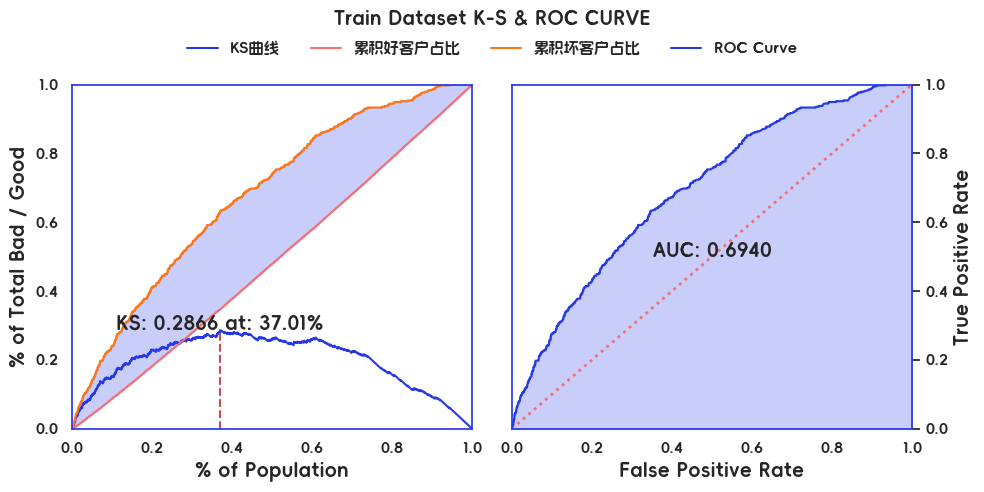

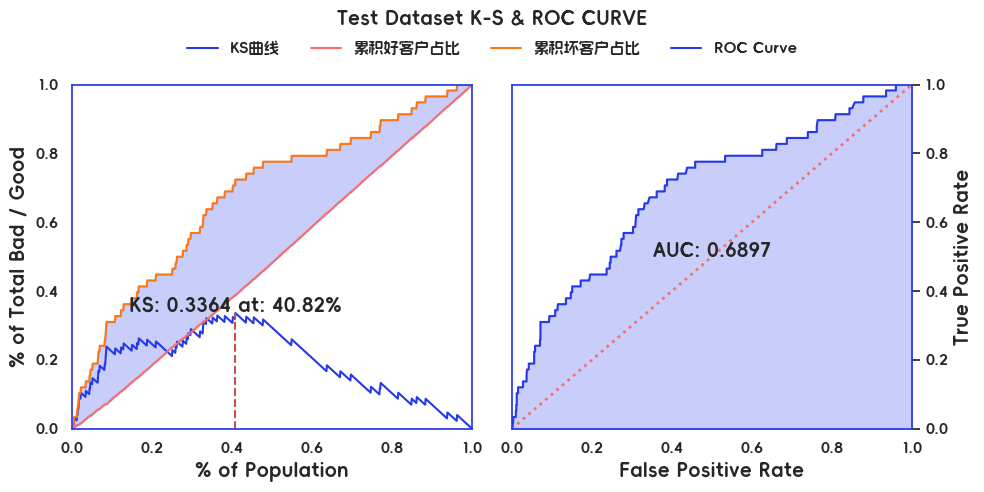

In [32]:
# 查看 KS 和 ROC 曲线
ks_plot(train["score"], train[target], figsize=(10,5),title="Train Dataset", save="model_report/sp_train_ksplot.png"); 
ks_plot(test["score"], test[target], figsize=(10,5),title="Test Dataset", save="model_report/sp_Test_ksplot.png"); 

In [33]:
# #测试集评分排序性
# score_clip_df_oot = card.score_clip(df_oot["score"], clip=20) # 计算等频分箱的间隔
# score_table_df_oot = feature_bin_stats(df_oot, "score", desc="df_oot模型评分", target='inst_7_ever_dpd15_flag', rules=score_clip_df_oot) # 计算统计信息
# bin_plot(score_table_df_oot, desc="df_oot模型评分", figsize=(10, 6), anchor=0.935, save="model_report/oot_score_bins.png"); # 画图
# score_table_df_oot

In [34]:
#测试集评分排序性
score_clip_test = card.score_clip(test["score"], clip=20) # 计算等频分箱的间隔
score_table_test = feature_bin_stats(test, "score", desc="测试集模型评分", target=target, rules=score_clip_test) # 计算统计信息
bin_plot(score_table_test, desc="测试集模型评分", figsize=(10, 6), anchor=0.935, save="model_report/test_score_bins.png"); 
score_table_test

,指标名称,指标含义,分箱,样本总数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,风险拒绝比,累积LIFT值,累积坏账改善,累积风险拒绝比,累积好样本数,累积坏样本数,分档KS值
0,score,测试集模型评分,"[负无穷 , 400)",30.0000,0.0315,23.0000,0.0257,7.0000,0.1207,0.2333,-1.5468,0.1469,0.9170,3.8339,0.0921,2.9260,0.0000,0.0000,0.0000,895.0000,58.0000,0.0000
1,score,测试集模型评分,"[400 , 420)",47.0000,0.0493,40.0000,0.0447,7.0000,0.1207,0.1489,-0.9934,0.0755,0.9170,2.4472,0.0751,1.5222,3.8339,-2.8339,-57.4620,872.0000,51.0000,-0.0950
2,score,测试集模型评分,"[420 , 440)",81.0000,0.0850,72.0000,0.0804,9.0000,0.1552,0.1111,-0.6569,0.0491,0.9170,1.8257,0.0767,0.9024,2.9875,-1.9875,-23.3833,832.0000,44.0000,-0.1710
3,score,测试集模型评分,"[440 , 460)",130.0000,0.1364,120.0000,0.1341,10.0000,0.1724,0.0769,-0.2515,0.0096,0.9170,1.2639,0.0417,0.3056,2.3919,-1.3919,-10.2034,760.0000,35.0000,-0.2457
4,score,测试集模型评分,"[460 , 480)",214.0000,0.2246,202.0000,0.2257,12.0000,0.2069,0.0561,0.0870,0.0016,0.9170,0.9214,-0.0228,-0.1014,1.8827,-0.8827,-3.9310,640.0000,25.0000,-0.2840
5,score,测试集模型评分,"[480 , 500)",199.0000,0.2088,195.0000,0.2179,4.0000,0.0690,0.0201,1.1503,0.1713,0.9170,0.3303,-0.1768,-0.8465,1.4729,-0.4729,-2.2647,438.0000,13.0000,-0.2652
6,score,测试集模型评分,"[500 , 520)",152.0000,0.1595,145.0000,0.1620,7.0000,0.1207,0.0461,0.2944,0.0122,0.9170,0.7567,-0.0462,-0.2895,1.1485,-0.1485,-0.9313,243.0000,9.0000,-0.1163
7,score,测试集模型评分,"[520 , 540)",64.0000,0.0672,62.0000,0.0693,2.0000,0.0345,0.0312,0.6976,0.0243,0.9170,0.5135,-0.0350,-0.5216,1.0787,-0.0787,-1.1720,98.0000,2.0000,-0.0750
8,score,测试集模型评分,"[540 , 正无穷)",36.0000,0.0378,36.0000,0.0402,0.0000,0.0000,0.0000,10.6022,0.4265,0.9170,0.0000,-0.0393,-1.0393,1.0393,-0.0393,-1.0393,36.0000,0.0000,-0.0402


In [35]:
# 数据字典或特征描述信息
feature_map = {
    "const": "截距项",
}

# summary 仅支持输出简单的统计信息，使用 summary2 可以输出有特征描述的统计信息表
logistic.summary2(feature_map=feature_map) 

,Features,Describe,Coef.,Std.Err,z,P>|z|,[ 0.025,0.975 ],VIF
0,const,截距项,0.0005,0.0298,0.0166,0.9868,-0.0578,0.0588,1.0883
1,仟盈信用分V1,,0.5366,0.0741,7.2417,0.0000,0.3914,0.6819,1.5558
2,仟盈通用反欺诈评分V4,,0.4328,0.1135,3.8145,0.0001,0.2104,0.6553,1.0655
3,yumingheng_test_sample__beta_pro_v1,,0.4346,0.0835,5.2030,0.0000,0.2709,0.5984,1.9786
4,yumingheng_test_sample__zc_score01,,0.2702,0.0844,3.2008,0.0014,0.1047,0.4357,2.1127
5,repay_succ6,,0.4322,0.1124,3.8452,0.0001,0.2119,0.6524,1.2907
6,m12_apply_time,,0.8258,0.1259,6.5602,0.0000,0.5791,1.0725,1.0242
7,lend_number12,,0.4372,0.1222,3.5787,0.0003,0.1977,0.6766,1.2351
8,apply_time1,,0.3159,0.3464,0.9118,0.3619,-0.3631,0.9949,1.0134
9,apply_time12,,0.4104,0.1594,2.5754,0.0100,0.0981,0.7228,1.0382


In [36]:
dataset_summary = logistic.summary2()

In [37]:
# 初始化 Excel 写入器
writer = ExcelWriter()

start_row, start_col = 2, 2

# ////////////////////////////////////// 样本说明 ///////////////////////////////////// #
worksheet = writer.get_sheet_by_name("汇总信息")

# 样本总体分布情况
end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value="样本总体分布情况", style="header")
end_row, end_col = dataframe2excel(dataset_summary, writer, worksheet, percent_cols=["样本占比", "坏客户占比"], start_row=end_row + 1)

# 建模样本时间分布情况
temp = distribution_plot(df, date="order_time", target=target, save="model_report/all_sample_time_count.png", result=True)
end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value="建模样本时间分布情况", style="header")
end_row, end_col = writer.insert_pic2sheet(worksheet, "model_report/all_sample_time_count.png", (end_row, start_col), figsize=(720, 370))
end_row, end_col = dataframe2excel(temp, writer, worksheet, percent_cols=["样本占比", "好样本占比", "坏样本占比", "坏样本率"], condition_cols=["坏样本率"], start_row=end_row)

In [38]:
# ////////////////////////////////////// 模型报告 ///////////////////////////////////// #
summary = logistic.summary2(feature_map=feature_map)

# 逻辑回归拟合情况
worksheet = writer.get_sheet_by_name("逻辑回归拟合结果")

end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value="逻辑回归拟合效果", style="header")
end_row, end_col = dataframe2excel(summary, writer, worksheet, condition_cols=["Coef."], start_row=end_row + 1)

end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value="训练数据集拟合报告", style="header")
end_row, end_col = dataframe2excel(logistic.report(train_woe), writer, worksheet, percent_cols=["precision", "recall", "f1-score"], start_row=end_row + 1)

end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value="测试数据集拟合报告", style="header")
end_row, end_col = dataframe2excel(logistic.report(test_woe), writer, worksheet, percent_cols=["precision", "recall", "f1-score"], start_row=end_row + 1)

In [39]:
psi_df_step = PSI(train_woe, test_woe)

In [40]:
# 变量分布情况
import toad
# 变量分布情况
feature_cols = list(card.rules.keys())

# 防止 card.rules 里有字段不在 df 中
feature_cols = [col for col in feature_cols if col in df.columns]

data_info = (
    toad.detect(df[feature_cols])
    .reset_index()
    .rename(columns={
        "index": "变量名称",
        "type": "变量类型",
        "size": "样本个数",
        "missing": "缺失值",
        "unique": "唯一值个数"
    })
)

# 关键：把 pandas dtype 类型转成字符串，否则 openpyxl 写不进去
data_info["变量类型"] = data_info["变量类型"].astype(str)

end_row, end_col = writer.insert_value2sheet(
    worksheet,
    (end_row + 2, start_col),
    value="变量分布情况",
    style="header"
)

end_row, end_col = writer.insert_df2sheet(
    worksheet,
    data_info,
    (end_row + 1, start_col)
)

# 变量相关性
data_corr = train_woe.corr()
logistic.corr(train_woe, save="model_report/train_corr.png", annot=False)
end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value="变量相关性", style="header")
end_row, end_col = writer.insert_pic2sheet(worksheet, "model_report/train_corr.png", (end_row + 1, start_col), figsize=(700, 500))
end_row, end_col = dataframe2excel(data_corr.reset_index().rename(columns={"index": ""}), writer, worksheet, color_cols=list(data_corr.columns), start_row=end_row + 1)

In [41]:
# 变量分箱信息
end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value="变量分箱信息", style="header")

for col in logistic.feature_names_in_:
    feature_table = feature_bin_stats(df, col, target=target, desc=feature_map.get(col, "") or "逻辑回归入模变量", combiner=combiner)
    _ = bin_plot(feature_table, desc=feature_map.get(col, "") or "逻辑回归入模变量", figsize=(8, 4), save=f"model_report/bin_plots/data_{col}.png")
    
    end_row, end_col = writer.insert_pic2sheet(worksheet, f"model_report/bin_plots/data_{col}.png", (end_row + 1, start_col), figsize=(700, 400))
    end_row, end_col = dataframe2excel(feature_table, writer, worksheet, percent_cols=["样本占比", "好样本占比", "坏样本占比", "坏样本率", "LIFT值", "累积LIFT值"], condition_cols=["坏样本率", "LIFT值"], start_row=end_row)

In [42]:
# ////////////////////////////////////// 评分卡说明 ///////////////////////////////////// #
worksheet = writer.get_sheet_by_name("评分卡结果")

# 评分卡刻度
scorecard_kedu = card.scorecard_scale()
scorecard_points = card.scorecard_points(feature_map=feature_map)
scorecard_clip = card.score_clip(train["score"], clip=20)

start_row, start_col = 2, 2
end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value="评分卡刻度", style="header")
end_row, end_col = writer.insert_df2sheet(worksheet, scorecard_kedu, (end_row + 1, start_col))

# 评分卡对应分数
end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value="评分卡分数", style="header")
end_row, end_col = writer.insert_df2sheet(worksheet, scorecard_points, (end_row + 1, start_col), merge_column="变量名称")

# 评分效果
score_table_train = feature_bin_stats(train, "score", desc="测试集模型评分", target=target, rules=scorecard_clip)
score_table_test = feature_bin_stats(test, "score", desc="测试集模型评分", target=target, rules=scorecard_clip)

ks_plot(train["score"], train[target], title="Train \tDataset", save="model_report/train_ksplot.png")
ks_plot(test["score"], test[target], title="Test \tDataset", save="model_report/test_ksplot.png")

hist_plot(train["score"], train[target], save="model_report/train_scorehist.png", bins=30)
hist_plot(test["score"], test[target], save="model_report/test_scorehist.png", bins=30)

end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value="训练数据集评分模型效果", style="header")
ks_row = end_row
end_row, end_col = writer.insert_pic2sheet(worksheet, "model_report/train_ksplot.png", (ks_row, start_col))
end_row, end_col = writer.insert_pic2sheet(worksheet, "model_report/train_scorehist.png", (ks_row, end_col))
end_row, end_col = dataframe2excel(score_table_train, writer, worksheet, percent_cols=["样本占比", "好样本占比", "坏样本占比", "坏样本率", "LIFT值", "累积LIFT值", "分档KS值"], condition_cols=["坏样本率", "LIFT值", "分档KS值"], start_row=end_row + 1)

end_row, end_col = writer.insert_value2sheet(worksheet, (end_row + 2, start_col), value="测试数据集评分模型效果", style="header")
ks_row = end_row
end_row, end_col = writer.insert_pic2sheet(worksheet, "model_report/test_ksplot.png", (ks_row, start_col))
end_row, end_col = writer.insert_pic2sheet(worksheet, "model_report/test_scorehist.png", (ks_row, end_col))
end_row, end_col = dataframe2excel(score_table_test, writer, worksheet, percent_cols=["样本占比", "好样本占比", "坏样本占比", "坏样本率", "LIFT值", "累积LIFT值", "分档KS值"], condition_cols=["坏样本率", "LIFT值", "分档KS值"], start_row=end_row + 1)

In [43]:
# ////////////////////////////////////// 模型稳定性 ///////////////////////////////////// #
worksheet = writer.get_sheet_by_name("模型稳定性")
start_row, start_col = 2, 2

# 评分分布稳定性
train_test_score_psi = psi_plot(score_table_train, score_table_test, labels=["训练数据集", "测试数据集"], save="model_report/train_test_psiplot.png", result=True)

end_row, end_col = writer.insert_value2sheet(worksheet, (start_row, start_col), value="模型评分稳定性指标 (Population Stability Index, PSI): 训练数据集 vs 测试数据集", style="header")
end_row, end_col = writer.insert_pic2sheet(worksheet, "model_report/train_test_psiplot.png", (end_row, start_col), figsize=(800, 400))
end_row, end_col = dataframe2excel(train_test_score_psi, writer, worksheet, percent_cols=["训练数据集样本占比", "训练数据集坏样本率", "测试数据集样本占比", "测试数据集坏样本率"], condition_cols=["分档PSI值"], start_row=end_row + 1)

In [44]:
# 变量 PSI 表
for col in card._feature_names:
    feature_table_train = feature_bin_stats(train, col, target=target, desc=feature_map.get(col, "") or "逻辑回归入模变量", combiner=combiner)
    feature_table_test = feature_bin_stats(test, col, target=target, desc=feature_map.get(col, "") or "逻辑回归入模变量", combiner=combiner)
    psi_table = psi_plot(feature_table_train, feature_table_test, desc=col, result=True, plot=True, max_len=35, figsize=(10, 6), labels=["训练数据集", "测试数据集"], save=f"model_report/psi_{col}.png");
    
    end_row, end_col = writer.insert_pic2sheet(worksheet, f"model_report/psi_{col}.png", (end_row, start_col), figsize=(700, 400))
    end_row, end_col = dataframe2excel(psi_table, writer, worksheet, percent_cols=["训练数据集样本占比", "训练数据集坏样本率", "测试数据集样本占比", "测试数据集坏样本率", "测试数据集% - 训练数据集%"], condition_cols=["分档PSI值"], start_row=end_row + 1);

In [45]:
# # 变量 csi 表
# for col in card._feature_names:
#     feature_table_train = feature_bin_stats(train, col, target=target, desc=feature_map.get(col, "") or "逻辑回归入模变量", combiner=combiner)
#     feature_table_test = feature_bin_stats(test, col, target=target, desc=feature_map.get(col, "") or "逻辑回归入模变量", combiner=combiner)
#     score_bins = card.rules[col]
#     csi_table = csi_plot(feature_table_train, feature_table_test, score_bins=score_bins, desc=col, result=True, plot=True, max_len=35, figsize=(10, 6), labels=["训练数据集", "测试数据集"], save=f"model_report/csi_{col}.png");
#     
#     end_row, end_col = writer.insert_pic2sheet(worksheet, f"model_report/csi_{col}.png", (end_row, start_col), figsize=(700, 400))
#     end_row, end_col = dataframe2excel(csi_table, writer, worksheet, percent_cols=["训练数据集样本占比", "训练数据集坏样本率", "测试数据集样本占比", "测试数据集坏样本率", "测试数据集% - 训练数据集%"], condition_cols=["分档CSI值"], start_row=end_row + 1);

In [46]:
# 2. 训练 / 测试集 IV
iv_train_raw = toad.IV(
    train_woe.drop(columns=[target]),
    train_woe[target]
)
iv_test_raw = toad.IV(
    test_woe.drop(columns=[target]),
    test_woe[target]
)

# toad.IV 返回的是 1 行 N 列的 DataFrame：取第 0 行，index 就是变量名
if isinstance(iv_train_raw, pd.DataFrame):
    iv_train = iv_train_raw.loc[0].copy()
else:
    iv_train = iv_train_raw.copy()
iv_train.name = 'IV_train'

if isinstance(iv_test_raw, pd.DataFrame):
    iv_test = iv_test_raw.loc[0].copy()
else:
    iv_test = iv_test_raw.copy()
iv_test.name = 'IV_test'

# 3. PSI 结果处理（psi_df_step）
# 假设 PSI(train_woe_stepwise, test_woe_stepwise) 返回 Series 或 DataFrame
if isinstance(psi_df_step, pd.DataFrame):
    # 如果有专门 PSI 列就按列名取，没有就取第一列
    psi_cols = [c for c in psi_df_step.columns if 'psi' in c.lower()]
    if psi_cols:
        psi_s = psi_df_step[psi_cols[0]].copy()
    else:
        psi_s = psi_df_step.iloc[:, 0].copy()
else:
    psi_s = psi_df_step.copy()
psi_s.name = 'PSI'

# 4. 按变量名对齐拼表
iv_psi_df = pd.concat([iv_train, iv_test, psi_s], axis=1)

# 如果不想要 target 那一行，可以删掉：
iv_psi_df = iv_psi_df.drop(index=target, errors='ignore')

# 5. 把变量名变成一列
iv_psi_df = iv_psi_df.reset_index().rename(columns={'index': 'feature'})

# ////////////////////////////////////// 特征概述 ///////////////////////////////////// #
worksheet = writer.get_sheet_by_name("模型变量信息")

# 标题行
start_row, start_col = 2, 2
end_row, end_col = writer.insert_value2sheet(
    worksheet,
    (start_row, start_col),
    value="变量 IV / PSI 信息",
    style="header"
)

# 整理 iv_psi_df，变成：序号 + 变量名 + 各指标
iv_psi_out = iv_psi_df.copy()

# 如果变量名在 index 上，就还原成一列；如果已经有 feature 列就改个中文名
if 'feature' in iv_psi_out.columns:
    iv_psi_out = iv_psi_out.rename(columns={'feature': '变量名'})
else:
    iv_psi_out = iv_psi_out.reset_index().rename(columns={'index': '变量名'})

# 加一个序号列
iv_psi_out.insert(0, "序号", range(1, len(iv_psi_out) + 1))

# 把 iv_psi_df 写到标题下面一行
end_row, end_col = writer.insert_df2sheet(
    worksheet,
    iv_psi_out,
    (end_row + 1, start_col)
)

In [47]:
# 保存结果文件
writer.save("analysisResults/评分卡模型报告_days180+_v1.xlsx")
print('保存成功')

保存成功
